# Reinforcement Learning Intro

**Author:** Ihor Melashchenko  
**Student ID:** C00290950

This notebook introduces reinforcement learning concepts with a simple educational environment and policy evaluation workflow.

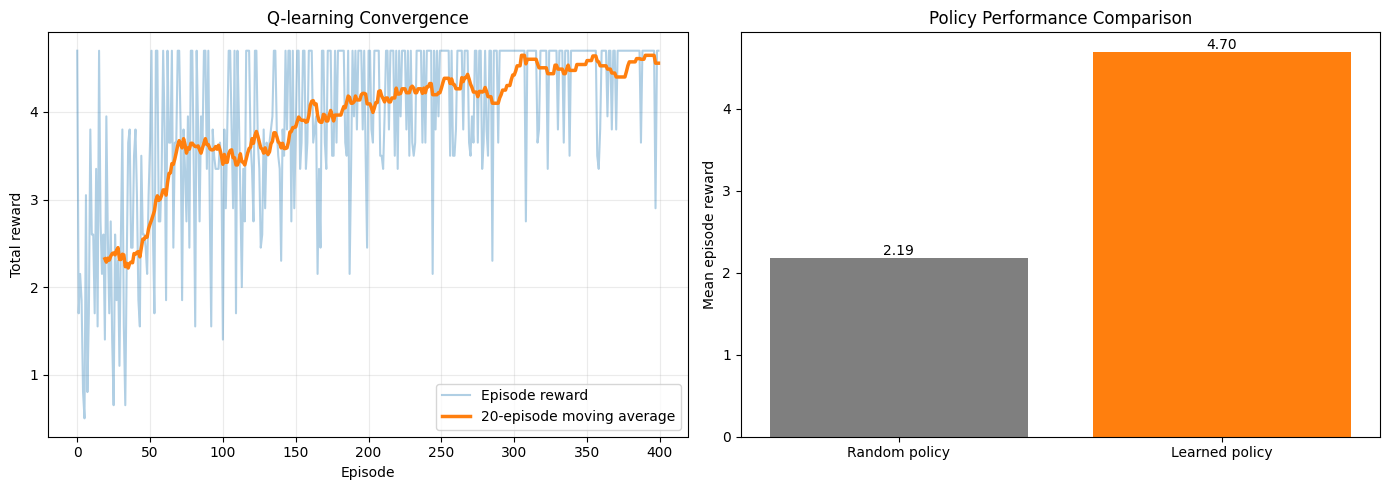

Learned Q-table:
[[2.562 3.918]
 [1.93  3.131]
 [1.296 2.346]
 [0.662 1.562]
 [0.03  0.78 ]
 [0.    0.   ]]
Random policy mean reward: 2.185
Learned policy mean reward: 4.700
Saved RL figure to: /Users/ihormelashchenko/GitHub/DS-and-ML-2-CA/results/figures/04_q_learning_results.png


In [1]:
# Author: Ihor Melashchenko
# Student ID: C00290950

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

class SimpleRetentionEnv:
    def __init__(self, max_state=5):
        self.max_state = max_state
        self.state = 0

    def reset(self):
        self.state = 0
        return self.state

    def step(self, action):
        # action 0: no intervention, action 1: intervention
        engagement_level = self.state / self.max_state
        if action == 1:
            reward = 1.1 - 0.4 * engagement_level
        else:
            reward = -0.25 + 0.35 * engagement_level

        self.state = min(self.state + 1, self.max_state)
        done = self.state >= self.max_state
        return self.state, reward, done

def evaluate_policy(env, policy_fn, episodes=200):
    episode_rewards = []
    for _ in range(episodes):
        state = env.reset()
        total_reward = 0.0
        done = False

        while not done:
            action = policy_fn(state)
            state, reward, done = env.step(action)
            total_reward += reward

        episode_rewards.append(total_reward)
    return np.array(episode_rewards)

env = SimpleRetentionEnv()
n_states = env.max_state + 1
n_actions = 2
q_table = np.zeros((n_states, n_actions))

alpha = 0.15
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.992
epsilon_min = 0.05
episodes = 400

training_rewards = []

for _ in range(episodes):
    state = env.reset()
    done = False
    episode_reward = 0.0

    while not done:
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = int(np.argmax(q_table[state]))

        next_state, reward, done = env.step(action)
        best_next = np.max(q_table[next_state])
        q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * best_next - q_table[state, action])

        state = next_state
        episode_reward += reward

    training_rewards.append(episode_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

random_rewards = evaluate_policy(env, policy_fn=lambda _: np.random.randint(0, 2), episodes=300)
learned_rewards = evaluate_policy(env, policy_fn=lambda s: int(np.argmax(q_table[s])), episodes=300)

window = 20
moving_average = np.convolve(training_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(training_rewards, alpha=0.35, label='Episode reward')
axes[0].plot(range(window - 1, episodes), moving_average, linewidth=2.5, label=f'{window}-episode moving average')
axes[0].set_title('Q-learning Convergence')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].grid(alpha=0.25)
axes[0].legend()

mean_random = random_rewards.mean()
mean_learned = learned_rewards.mean()
axes[1].bar(['Random policy', 'Learned policy'], [mean_random, mean_learned], color=['tab:gray', 'tab:orange'])
axes[1].set_title('Policy Performance Comparison')
axes[1].set_ylabel('Mean episode reward')
for idx, value in enumerate([mean_random, mean_learned]):
    axes[1].text(idx, value + 0.03, f'{value:.2f}', ha='center')

fig.tight_layout()
figure_path = Path.cwd().parent / 'results' / 'figures' / '04_q_learning_results.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

print('Learned Q-table:')
print(np.round(q_table, 3))
print(f'Random policy mean reward: {mean_random:.3f}')
print(f'Learned policy mean reward: {mean_learned:.3f}')
print('Saved RL figure to:', figure_path)

## Interpretation
- The reward trend and moving-average curve indicate policy improvement over episodes.
- Learned-policy average reward should exceed the random-policy baseline.
- This provides a minimal RL baseline for intervention-policy optimization in the final portfolio scope.